In [1]:
# ===== 1. IMPORTS =====
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import sys

# Make the src/ package importable from within the notebooks/ subfolder.
sys.path.append("..")

# import constants and functions from our src/ modules to keep the notebook clean 
# and focused on the data.
from src import config 
from src.feature_prefilter import prefilter_features 
from src.ga_feature_selection import run_ga

In [2]:
# ===== 2. LOAD PRE-PROCESSED DATA =====
# use split and scaled data from 01_dataset_inspection.ipynb
with open("../data/processed/uci_full/uci_full_split_scaled.pkl", "rb") as f:
    X_train_scaled, X_test_scaled, y_train, y_test = pickle.load(f)

In [3]:
# ===== 3. PREFILTER FEATURES WITH MUTUAL INFORMATION =====
# quick prefiltering step to remove obviously irrelevant features and speed up the GA.
X_train_ga, X_test_ga, selected_prefilter_features, mi_series = prefilter_features(
    X_train_scaled,
    X_test_scaled,
    y_train,
    k=config.TOP_K_FEATURES,
    seed=config.SEED
)

print("Features before prefilter:", X_train_scaled.shape[1])
print("Features after prefilter:", X_train_ga.shape[1])

# Show the top-20 features
mi_series.head(20)

Features before prefilter: 111
Features after prefilter: 50


directory_length           0.380519
qty_slash_url              0.379696
qty_slash_directory        0.376068
qty_dot_directory          0.352792
file_length                0.350651
qty_dot_file               0.350478
qty_hyphen_directory       0.344418
qty_at_file                0.337838
qty_equal_file             0.337670
qty_dollar_directory       0.337174
qty_equal_directory        0.336795
qty_and_directory          0.336463
qty_underline_directory    0.336055
qty_tilde_file             0.335947
qty_and_file               0.335901
qty_space_directory        0.335426
qty_hashtag_directory      0.335400
qty_comma_directory        0.335373
qty_hyphen_file            0.335351
qty_tilde_directory        0.335294
dtype: float64

In [4]:
# ===== 4. RUN THE GENETIC ALGORITHM =====
# run
best_chromosome, best_fitness, selected_features, best_hist, avg_hist = run_ga(
    X_train_ga,
    y_train,
    pop_size=config.POP_SIZE,
    n_generations=config.N_GENERATIONS,
    mutation_rate=config.MUTATION_RATE,
    crossover_rate=config.CROSSOVER_RATE,
    tournament_size=config.TOURNAMENT_SIZE,
    early_stop_patience=config.EARLY_STOP_PATIENCE,
    min_improvement=config.MIN_IMPROVEMENT,
    seed=config.SEED
)

print("Best fitness:", best_fitness)
print("Selected feature count:", len(selected_features))
print(selected_features)

Generation   1 | Best: 0.9295 | Avg: 0.9060
Generation   2 | Best: 0.9333 | Avg: 0.9169
Generation   3 | Best: 0.9329 | Avg: 0.9245
Generation   4 | Best: 0.9327 | Avg: 0.9273
Generation   5 | Best: 0.9334 | Avg: 0.9296
Generation   6 | Best: 0.9334 | Avg: 0.9308
Generation   7 | Best: 0.9339 | Avg: 0.9320
Early stopping triggered.
Best fitness: 0.9333301102301296
Selected feature count: 25
['qty_slash_url', 'qty_slash_directory', 'qty_dot_directory', 'file_length', 'qty_hyphen_directory', 'qty_equal_directory', 'qty_underline_directory', 'qty_space_directory', 'qty_comma_directory', 'qty_tilde_directory', 'qty_underline_file', 'qty_asterisk_file', 'qty_space_file', 'qty_exclamation_directory', 'qty_slash_file', 'qty_asterisk_directory', 'qty_percent_directory', 'length_url', 'time_domain_activation', 'asn_ip', 'ttl_hostname', 'qty_percent_params', 'qty_tilde_params', 'qty_dot_domain', 'qty_hashtag_params']


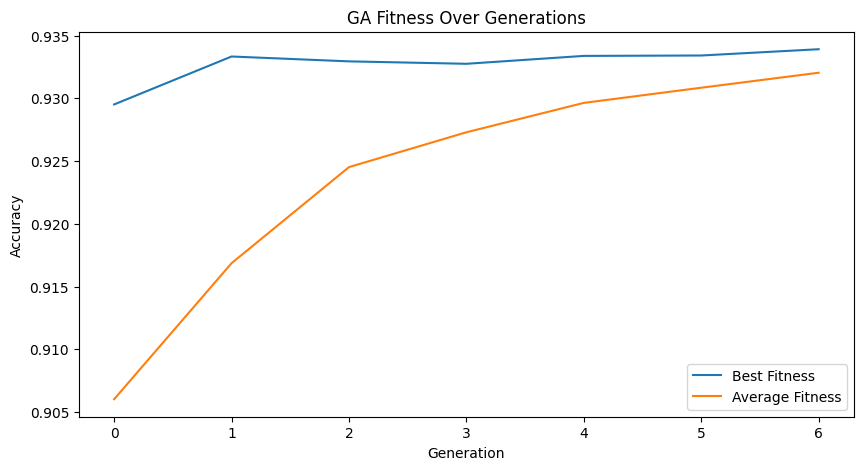

In [5]:
# ===== 5. PLOT GA CONVERGENCE =====
# plot the best and average fitness over generations to visualize convergence.
plt.figure(figsize=(10, 5))
plt.plot(best_hist, label="Best Fitness")
plt.plot(avg_hist, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("GA Fitness Over Generations")
plt.legend()
plt.show()

In [6]:
# ===== 6. SAVE GA RESULTS =====
# Save the selected features and GA history for later use in model evaluation and plotting.
with open("../data/processed/uci_full/uci_full_selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

with open("../data/processed/uci_full/uci_full_ga_history.pkl", "wb") as f:
    pickle.dump((best_hist, avg_hist), f)